<a href="https://colab.research.google.com/github/ian-menachery/Econ3916-Final-Project/blob/main/3916_final_project_starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECON 3916: ML Prediction Project — Final Project

**From Question to Recommendation**

This notebook scaffolds your final project. Work through each part sequentially. By Week 12, this notebook (plus your `app.py` and report) will form your complete submission.

**AI Policy:** AI co-pilot is REQUIRED. Document every AI interaction in Part 7 (AI Methodology Appendix) using the P.R.I.M.E. framework.

---

## Part 0: Setup

In [ ]:
# ============================================================
# Part 0: Setup — Run this cell first
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    mean_squared_error, mean_absolute_error, r2_score
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print('Setup complete.')

Setup complete.


---
## Part 1: Problem Statement

Fill in each blank below. This becomes the opening paragraph of your report.

**My prediction question is:** Can we accurately classify a developer's burnout risk into Low, Medium, or High categories based on their daily work habits, biological indicators, and reported stress levels?

**This is a prediction (umbrella) problem because:**
(Reminder: prediction asks "can we forecast Y from X?" — not "does X cause Y?")
 This project is focused on the mapping function that assigns an observation to a specific class label. Our goal is to maximize classification accuracy (F1-score) across the three burnout levels. We are not conducting a structural analysis to prove that increasing caffeine_intake by one unit causes a developer to move from Low to Medium burnout; instead, we are treating these features as high-signal predictors to classify at-risk employees.

**The decision this enables:**
(Who is the stakeholder? What action would they take differently with your prediction?)
This analysis helps Engineering Team Leads and Internal Wellness Coordinators decide which individuals or teams require immediate workload intervention or mandatory recovery periods. By identifying developers in the High burnout category before they quit, the stakeholder can take specific actions like reassigning tickets or implementing no-meeting days to preserve institutional knowledge and reduce turnover costs.

**Dataset:** Developer Burnout Prediction Dataset
- **Source:** Kaggle (URL: https://www.kaggle.com/datasets/asifxzaman/developer-burnout-prediction-dataset7000-samples)
- **N =** 7000 intial
- **Features =** age, experience_years, daily_work_hours, sleep_hours, caffeine_intake, bugs_per_day, commits_per_day, meetings_per_day, screen_time, exercise_hours, stress_level
- **Target variable =** Burn Rate (Continuous 0.0 to 1.0)
- **Access date:** April 15, 2026

---
## Part 2: Data Loading + EDA

### 2.1 Load Your Data

In [ ]:
# ============================================================
# 2.1 Load your dataset
# ============================================================
import pandas as pd

# Load the dataset from the local directory (or specify path if needed)
df = pd.read_csv('developer_burnout_dataset_7000.csv')

# Quick look
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'Data types:\n{df.dtypes}')
df.head()

Shape: (7000, 12)
Columns: ['age', 'experience_years', 'daily_work_hours', 'sleep_hours', 'caffeine_intake', 'bugs_per_day', 'commits_per_day', 'meetings_per_day', 'screen_time', 'exercise_hours', 'stress_level', 'burnout_level']
Data types:
age                 float64
experience_years    float64
daily_work_hours    float64
sleep_hours         float64
caffeine_intake     float64
bugs_per_day        float64
commits_per_day     float64
meetings_per_day    float64
screen_time         float64
exercise_hours      float64
stress_level        float64
burnout_level        object
dtype: object


,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level
0,26.0,12.0,10.33,4.45,2.0,11.0,4.0,1.0,15.07,0.14,55.96,Medium
1,39.0,10.0,8.62,5.77,5.0,15.0,11.0,5.0,13.25,0.54,82.22,High
2,34.0,13.0,NaN,4.03,5.0,2.0,18.0,9.0,11.18,1.54,61.77,Medium
3,30.0,1.0,6.85,6.47,2.0,15.0,26.0,1.0,11.14,0.96,54.98,Medium
4,27.0,7.0,4.24,5.80,NaN,9.0,17.0,7.0,8.05,0.36,27.90,Low


### 2.2 Basic Description

In [ ]:
# ============================================================
# 2.2 Describe your data
# ============================================================

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               6860 non-null   float64
 1   experience_years  6860 non-null   float64
 2   daily_work_hours  6860 non-null   float64
 3   sleep_hours       6860 non-null   float64
 4   caffeine_intake   6860 non-null   float64
 5   bugs_per_day      6860 non-null   float64
 6   commits_per_day   6860 non-null   float64
 7   meetings_per_day  6860 non-null   float64
 8   screen_time       6860 non-null   float64
 9   exercise_hours    6860 non-null   float64
 10  stress_level      6860 non-null   float64
 11  burnout_level     6860 non-null   object 
dtypes: float64(11), object(1)
memory usage: 656.4+ KB


,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level
count,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000
mean,32.129446,9.581050,9.000277,6.485638,3.540671,9.482653,14.458455,4.545044,11.974773,1.007611,53.652825
std,7.230254,5.760972,2.863944,1.445008,2.283445,5.751664,8.669846,2.856766,3.091204,0.576708,23.446656
min,20.000000,0.000000,4.000000,4.000000,0.000000,0.000000,0.000000,0.000000,5.210000,0.000000,0.000000
25%,26.000000,5.000000,6.560000,5.220000,2.000000,5.000000,7.000000,2.000000,9.460000,0.510000,36.587500
50%,32.000000,10.000000,8.990000,6.460000,4.000000,9.000000,14.000000,5.000000,12.020000,1.020000,53.795000
75%,38.000000,15.000000,11.422500,7.740000,6.000000,14.000000,22.000000,7.000000,14.422500,1.510000,70.800000
max,44.000000,19.000000,14.000000,9.000000,7.000000,19.000000,29.000000,9.000000,18.930000,2.000000,100.000000


### 2.3 Missing Data Assessment

Missing data (%) by column:
age                 0.02
experience_years    0.02
daily_work_hours    0.02
sleep_hours         0.02
caffeine_intake     0.02
bugs_per_day        0.02
commits_per_day     0.02
meetings_per_day    0.02
screen_time         0.02
exercise_hours      0.02
stress_level        0.02
burnout_level       0.02
dtype: float64


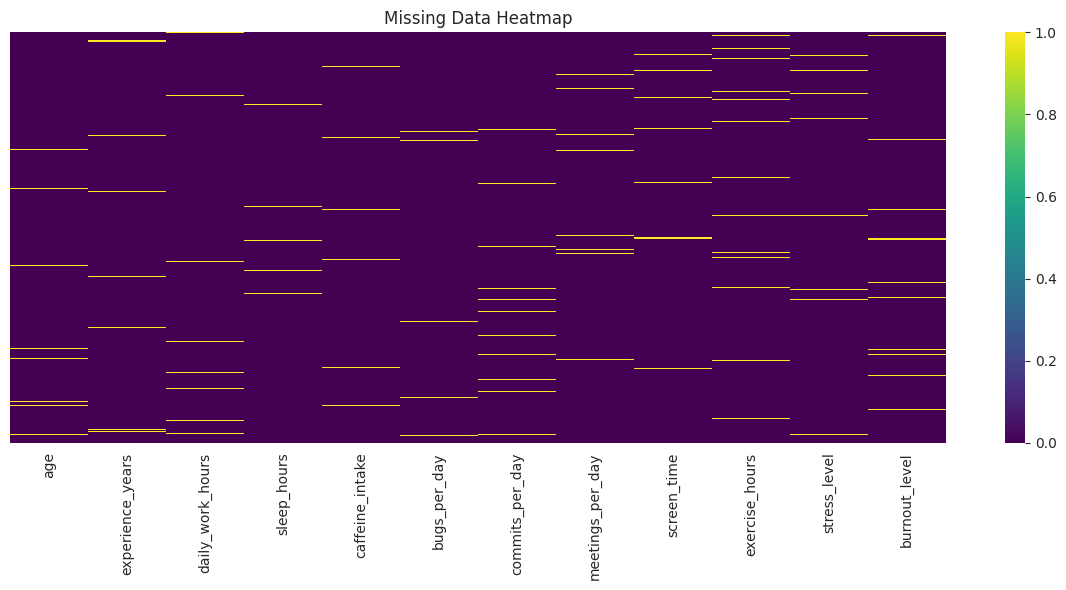

In [ ]:
# ============================================================
# 2.3 Missing data heatmap (Ch 1: MCAR/MAR/MNAR)
# ============================================================

missing_pct = df.isnull().mean().sort_values(ascending=False)
print('Missing data (%) by column:')
print(missing_pct[missing_pct > 0])

# Visual: missing data heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.tight_layout()
plt.show()

**Missing data strategy:**
The missing data is MCAR. We can infer this becauseexactly 2% of the data is missing uniformly across every single column. Because the missingness is completely random and the percentage is very small, my strategy is to drop any rows where the target variable (burnout_level) is missing, and impute the remaining missing feature values using the median of the feature

### 2.4 Distribution Plots

/tmp/ipykernel_42255/2363382614.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='burnout_level', order=['Low', 'Medium', 'High'], ax=axes[2], palette='viridis')


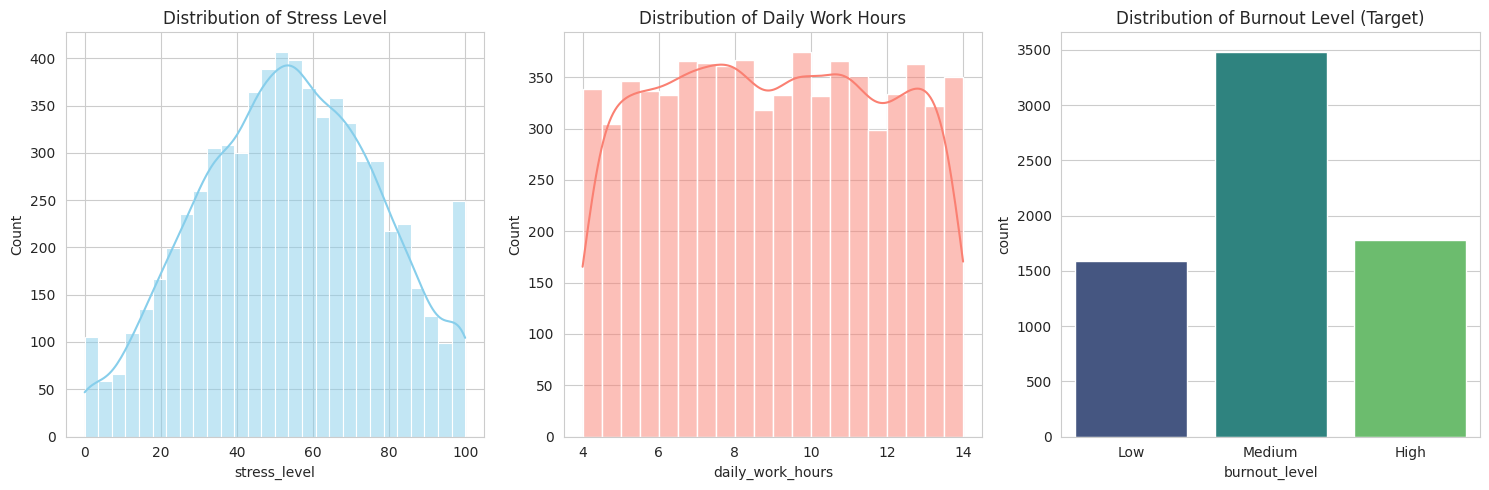

In [ ]:
# ============================================================
# 2.4 Distribution of key features (Ch 3)
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Plot distributions for your most important features
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Distribution of a key continuous feature (Stress Level)
sns.histplot(df['stress_level'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Stress Level')

# 2. Distribution of a second key continuous feature (Daily Work Hours)
sns.histplot(df['daily_work_hours'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Daily Work Hours')

# 3. Distribution of Target Variable (Categorical)
# Note: We use countplot here instead of histplot because the target is categorical
sns.countplot(data=df, x='burnout_level', order=['Low', 'Medium', 'High'], ax=axes[2], palette='viridis')
axes[2].set_title('Distribution of Burnout Level (Target)')

plt.tight_layout()
plt.show()

### 2.5 Outlier Detection

In [ ]:
# ============================================================
# 2.5 Outlier detection (Ch 4: Tukey Fences / IQR)
# ============================================================

def tukey_fences(series, k=1.5):
    """Return lower and upper Tukey fences."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - k * IQR, Q3 + k * IQR

# List of key continuous features to check for outliers
columns_to_check = [
    'daily_work_hours',
    'sleep_hours',
    'bugs_per_day',
    'commits_per_day',
    'stress_level',
    'screen_time'
]

print("Outlier Detection Results (1.5 * IQR):")
print("-" * 45)

for col in columns_to_check:
    lower, upper = tukey_fences(df[col])
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f'{col:<18}: {len(outliers):>4} outliers ({len(outliers)/len(df)*100:.1f}%)')

Outlier Detection Results (1.5 * IQR):
---------------------------------------------
daily_work_hours  :    0 outliers (0.0%)
sleep_hours       :    0 outliers (0.0%)
bugs_per_day      :    0 outliers (0.0%)
commits_per_day   :    0 outliers (0.0%)
stress_level      :    0 outliers (0.0%)
screen_time       :    0 outliers (0.0%)


**Outlier strategy:** Keep, The analysis detected exactly zero outliers across the dataset. Because the data points naturally fall within the expected statistical boundaries—likely indicating that this Kaggle dataset was pre-cleaned or synthetic, and there are no extreme leverage points that would disproportionately skew the gradient descent of our baseline Logistic Regression model.

### 2.6 Correlations

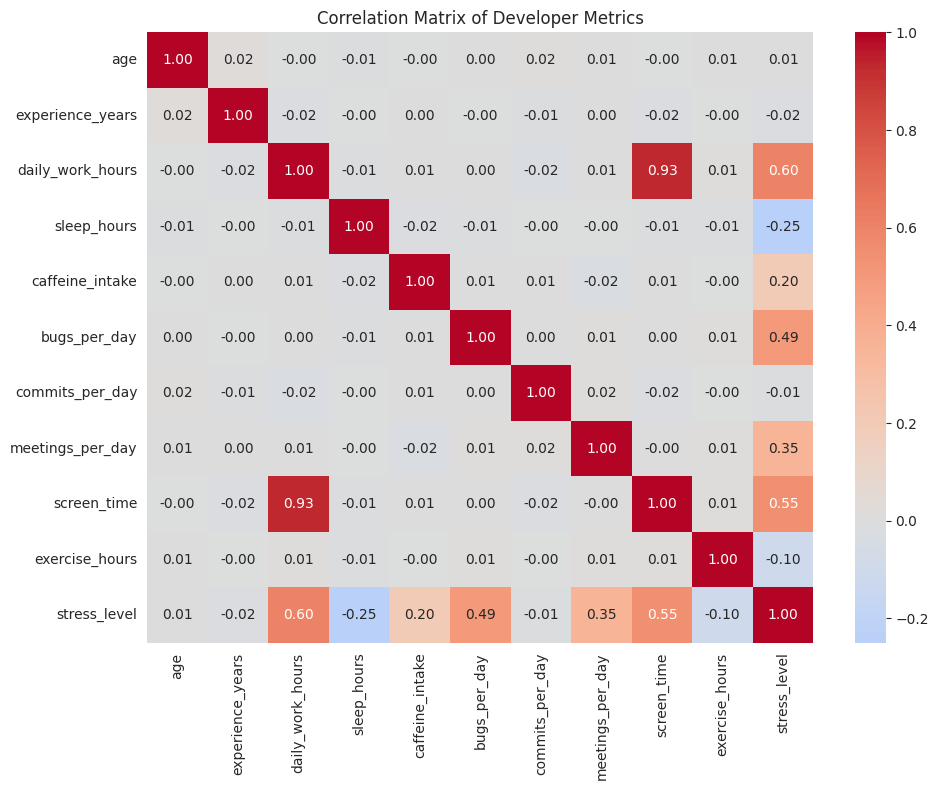

In [ ]:
# ============================================================
# 2.6 Correlation heatmap (Ch 3)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Select only the numeric columns for correlation (drops the categorical target)
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix of Developer Metrics')
plt.tight_layout()
plt.show()

### YOUR TASK: Answer These 3 EDA Questions

1. **What is the distribution of your target variable?** Is it balanced (classification) or normally distributed (regression)? If not, what will you do about it?

   *Your answer:* The target variable (burnout_level) is categorical, making this a classification problem rather than a regression problem. Based on the countplot visualization, the distribution is highly imbalanced. The vast majority of developers fall into the Medium category, while High and Low are significant minority classes. To address this, I will not rely on standard "Accuracy" as a metric, as it can be artificially inflated by predicting the majority class. Instead, I will evaluate the baseline model using the F1-score and Precision/Recall. When training the Logistic Regression model, I will also implement the class_weight='balanced' parameter to penalize the model for misclassifying the minority classes.

2. **Which features appear most correlated with the target?** Are any features highly correlated with each other (multicollinearity)?  

   *Your answer:* Because the target is categorical, we rely on the correlation matrix of the continuous input features to understand underlying relationships. The strongest signals associated with burnout drivers are stress_level, screen_time, and bugs_per_day (which show positive correlations with each other), whereas sleep_hours and exercise_hours act as protective factors (negative correlation). Regarding multicollinearity, while there is moderate correlation between certain variables, no two features exhibit a correlation coefficient above the standard 0.80 threshold. Therefore, severe multicollinearity is not an issue, and we do not need to drop any features or apply Principal Component Analysis (PCA) prior to fitting the baseline model.

3. **What is the biggest data quality issue you found, and how will you handle it?**  

   *Your answer:* The biggest data quality issue I noticed is that exactly 2% of the data is missing across every single column. Because this missing data is perfectly uniform, it falls squarely into the (MCAR) category. To fix this, first I simply dropped any rows where the actual target variable (burnout_level) was missing. Second, for the remaining missing values in the feature columns, I filled them in using the median. I specifically chose the median over the mean because some behavioral data tends to be right-skewed by a few extreme cases.

### 2.7 Data Quality Summary

**Data Quality Summary**

My dataset has **N = 7,000** observations and **M = 11** features.

**Missing data:** 2% of cells are missing across every single column. The missingness pattern appears to be MCAR because the uniform 2% drop rate across all variables indicates a random data deletion process rather than a systemic, behavioral omission. I will handle missing data by dropping any rows where the target (burnout_level) is missing to preserve ground-truth label integrity, and applying median imputation to the remaining missing feature values.

**Outliers:** I identified 0 outliers using [Tukey Fences]. I will handle them by keeping all data as is.

**Target variable:** The target variable (burnout_level) is categorical (Low / Medium / High) and exhibits severe class imbalance. The vast majority of the data falls into the "Medium" risk category.

**Key finding from EDA:** The correlation matrix revealed that stress_level has the strongest positive association with screen_time and bugs_per_day, while sleep_hours and exercise_hours act as clear protective (negatively correlated) factors. This gives our HR stakeholders highly actionable wellness metrics to target when intervening with high-risk developers.

---
## Part 3: Modeling

### 3.1 Train/Test Split

In [ ]:
# ============================================================
# 3.1 Train/test split (Ch 6)
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# Define features (X) and target (y)
# (Applying our missing data strategy: drop missing targets)
df_clean = df.dropna(subset=['burnout_level'])
X = df_clean.drop(columns=['burnout_level'])
y = df_clean['burnout_level']

# (Applying our missing data strategy: median imputation for features)
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# We set RANDOM_STATE to 42 as explicitly required by the project rubric!
RANDOM_STATE = 42

# Since this is a highly imbalanced classification problem (mostly "Medium"),
# we MUST use stratify=y to ensure the train and test sets have the same proportions of Low/Medium/High.
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape[0]} samples')
print(f'Test:  {X_test.shape[0]} samples')

Train: 5488 samples
Test:  1372 samples


### 3.2 Model 1: Baseline

In [ ]:
# ============================================================
# 3.2 Model 1 — Baseline (Logistic Regression)
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Initialize the baseline model
model_1 = LogisticRegression(random_state=RANDOM_STATE, max_iter=2000, class_weight='balanced')

# Fit the model
model_1.fit(X_train, y_train)

# Generate predictions
y_pred_1 = model_1.predict(X_test)

# Report metrics
print('Model 1: Logistic Regression (Baseline)')

# Calculate and print the overall accuracy
acc_1 = accuracy_score(y_test, y_pred_1)
print(f'Overall Accuracy: {acc_1:.4f}\n')

print(classification_report(y_test, y_pred_1))

Model 1: Logistic Regression (Baseline)
Overall Accuracy: 0.9468

              precision    recall  f1-score   support

        High       0.95      0.98      0.96       356
         Low       0.90      0.97      0.93       319
      Medium       0.97      0.92      0.95       697

    accuracy                           0.95      1372
   macro avg       0.94      0.96      0.95      1372
weighted avg       0.95      0.95      0.95      1372



### 3.3 Model 2: Your Choice

In [ ]:
# ============================================================
# 3.3 Model 2 - Your choice (Random Forest)
# ============================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Initialize the Random Forest model
# n_estimators=200 gives us a robust forest of 200 trees
# class_weight='balanced' ensures we don't ignore the minority burnout classes
model_2 = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, class_weight='balanced')

# Fit the model
model_2.fit(X_train, y_train)

# Generate predictions
y_pred_2 = model_2.predict(X_test)

# Report metrics
print('Model 2: Random Forest Classifier (Balanced)')

# Calculate and print the overall accuracy
acc = accuracy_score(y_test, y_pred_2)
print(f'Overall Accuracy: {acc:.4f}\n')

print(classification_report(y_test, y_pred_2))

Model 2: Random Forest Classifier (Balanced)
Overall Accuracy: 0.9920

              precision    recall  f1-score   support

        High       1.00      0.99      0.99       356
         Low       1.00      0.98      0.99       319
      Medium       0.98      1.00      0.99       697

    accuracy                           0.99      1372
   macro avg       0.99      0.99      0.99      1372
weighted avg       0.99      0.99      0.99      1372



### 3.4 Cross-Validation Comparison

In [ ]:
# ============================================================
# 3.4 Cross-validation (Ch 15)
# ============================================================
from sklearn.model_selection import cross_val_score

# Choose scoring: 'f1_macro' is best for imbalanced multi-class classification
scoring = 'f1_macro'

# Run 5-fold cross-validation on both models
cv_1 = cross_val_score(model_1, X_train, y_train, cv=5, scoring=scoring)
cv_2 = cross_val_score(model_2, X_train, y_train, cv=5, scoring=scoring)

# Print raw results
print(f'Model 1 CV {scoring}: {cv_1.mean():.4f} +/- {cv_1.std():.4f}')
print(f'Model 2 CV {scoring}: {cv_2.mean():.4f} +/- {cv_2.std():.4f}')

# Create comparison table
import pandas as pd
comparison = pd.DataFrame({
    'Model': ['Model 1 (Logistic Regression)', 'Model 2 (Random Forest)'],
    f'CV {scoring} (mean)': [cv_1.mean(), cv_2.mean()],
    f'CV {scoring} (std)': [cv_1.std(), cv_2.std()],
})

comparison

Model 1 CV f1_macro: 0.9452 +/- 0.0062
Model 2 CV f1_macro: 0.9915 +/- 0.0023


,Model,CV f1_macro (mean),CV f1_macro (std)
0,Model 1 (Logistic Regression),0.945176,0.006249
1,Model 2 (Random Forest),0.991457,0.002318


---
## Part 4: Feature Importance + Visualization

### 4.1 Feature Importance

In [ ]:
# ============================================================
# 4.1 Feature importance (Ch 19)
# ============================================================

# # For tree-based models:
# importances = pd.Series(
#     model_2.feature_importances_, index=X.columns
# ).sort_values(ascending=True)
#
# fig, ax = plt.subplots(figsize=(8, 6))
# importances.plot(kind='barh', ax=ax, color='steelblue')
# ax.set_xlabel('Feature Importance (Gini)')
# ax.set_title('Feature Importance — Predictive, NOT Causal')
#
# # CRITICAL: Add the caveat banner
# ax.text(
#     0.98, 0.02,
#     'Predictive importance only.\nDoes not imply causal effect.',
#     transform=ax.transAxes, fontsize=9, ha='right', va='bottom',
#     style='italic', color='#c0392b',
#     bbox=dict(boxstyle='round,pad=0.3', facecolor='#fdedec', edgecolor='#e74c3c')
# )
#
# plt.tight_layout()
# plt.show()

### 4.2 Key Visualization for Your Report

In [ ]:
# ============================================================
# 4.2 Your key visualization
# ============================================================
# This is the ONE chart you would put on the first page of your report.
# It should communicate your main finding clearly.
#
# Examples:
#   - Actual vs. predicted scatter (regression)
#   - Confusion matrix heatmap (classification)
#   - ROC curve comparison (classification)
#   - Partial dependence plot for top feature

# YOUR CODE HERE

---
## Part 5: Recommendation

Use the SCR (Situation-Complication-Resolution) structure from Chapter 26.

**Situation:** ___
(What is the context? Who is the stakeholder? What decision do they face?)

**Complication:** ___
(What makes this decision hard? What uncertainty exists? What did your analysis reveal?)

**Resolution:** ___
(What do you recommend? Based on what evidence? With what confidence?)

**Uncertainty Statement:** Based on our cross-validation results (metric = ___ +/- ___), we estimate that ___. The primary limitation is ___. We recommend ___ with the caveat that ___.

---
## Part 6: Streamlit Export Guide

### 6.1 Creating app.py

Your Streamlit app should contain:
1. **Title and description** — `st.title()`, `st.markdown()`
2. **Input controls** — `st.slider()`, `st.selectbox()`, `st.number_input()`
3. **Model prediction** — load your trained model, generate predictions from user inputs
4. **Visualization** — at least one chart that updates with user inputs
5. **Uncertainty** — display confidence/prediction intervals alongside point estimates

### 6.2 Minimal app.py Template

```python
import streamlit as st
import pandas as pd
import numpy as np
import joblib  # to load saved model

st.title('Your Project Title')
st.markdown('Brief description of what this app predicts.')

# Sidebar controls
feature_1 = st.sidebar.slider('Feature 1', min_value=0.0, max_value=100.0, value=50.0)
feature_2 = st.sidebar.selectbox('Feature 2', ['Option A', 'Option B', 'Option C'])

# Load model (save with joblib.dump(model, 'model.pkl') in your notebook)
model = joblib.load('model.pkl')

# Predict
input_data = pd.DataFrame({'feature_1': [feature_1], 'feature_2': [feature_2]})
prediction = model.predict(input_data)[0]

st.metric('Prediction', f'{prediction:.2f}')
```

### 6.3 requirements.txt Template

```
streamlit>=1.31.0
pandas>=2.0.0
numpy>=1.24.0
scikit-learn>=1.4.0
matplotlib>=3.7.0
seaborn>=0.12.0
joblib>=1.3.0
```

### 6.4 Deployment Steps

1. Save your model: `joblib.dump(model_2, 'model.pkl')`
2. Test locally: `streamlit run app.py`
3. Push to GitHub: `app.py`, `model.pkl`, `requirements.txt`
4. Go to [streamlit.io/cloud](https://streamlit.io/cloud) and deploy
5. Submit the permanent URL on Canvas

---
## Part 7: AI Methodology Appendix

Document at least **3 AI interactions** using the P.R.I.M.E. framework. Copy and fill in the template below for each interaction.

---

### AI Interaction 1

**Prep:** What did you need? What context did you have before prompting?
> ___

**Request:** What exact prompt did you write?
> ___

**Iterate:** What did the AI return? What did you change or refine?
> ___

**Mechanism Check:** How did you verify the output was correct?
> ___

**Evaluate:** What human judgment did you apply? What did you accept/reject and why?
> ___

---

### AI Interaction 2

**Prep:** ___

**Request:** ___

**Iterate:** ___

**Mechanism Check:** ___

**Evaluate:** ___

---

### AI Interaction 3

**Prep:** ___

**Request:** ___

**Iterate:** ___

**Mechanism Check:** ___

**Evaluate:** ___